In [6]:
import pandas as pd
import numpy as np
import talib.abstract as ta

In [3]:
def getHigherHighs(series, width=5, K=2):
  '''
  Finds consecutive higher highs in price pattern.
  Must not be exceeded within the number of periods indicated by the width 
  parameter for the value to be confirmed.
  K determines how many consecutive highs need to be higher.
  '''
  # Get highs
  high_idx = argrelextrema(df, np.greater, width=width)[0]
  # 解决未来函数问题
  high_idx = high_idx + width
  high_idx = high_idx[high_idx < len(arr)]
  highs = df[high_idx]
  # Ensure consecutive highs are higher than previous highs
  extrema = []
  ex_deque = deque(maxlen=K)
  for i, idx in enumerate(high_idx):
    if i == 0:
      ex_deque.append(idx)
      continue
    if highs[i] < highs[i-1]:
      ex_deque.clear()
 
    ex_deque.append(idx)
    if len(ex_deque) == K:
      extrema.append(ex_deque.copy())
   
  return extrema

In [8]:
df = pd.read_csv('bitcoin.csv')

In [9]:
test = df.tail(1000)

In [10]:
test.iloc[9]['Close']

47236.64

In [11]:
import pandas as pd
import numpy as np

# 假设Data是一个DataFrame，包含至少两列：价格和RSI
# 初始化divergence列
df['divergence'] = np.nan

lower_barrier = 30
upper_barrier = 70
width = 5

def get_rsi_divergence(df: pd.DataFrame, width=5) -> pd.Series:
    # Bullish Divergence
    for i in range(len(df) - width):  # 确保有足够的数据进行比较
        if df.iloc[i]['rsi'] < lower_barrier:

            for a in range(i + 1, min(i + width + 1, len(df))):
                if df.iloc[a]['rsi'] > lower_barrier:
                    
                    for r in range(a + 1, min(a + width + 1, len(df))):
                        if df.iloc[r]['rsi'] < lower_barrier and df.iloc[r]['rsi'] > df.iloc[i]['rsi'] and df.iloc[r]['Close'] < df.iloc[i]['Close']:
                            df.loc[r, 'divergence'] = 1
                            break

    # Bearish Divergence
    for i in range(len(df) - width):  # 确保有足够的数据进行比较
        if df.iloc[i, 'rsi'] > upper_barrier:
            for a in range(i + 1, min(i + width + 1, len(df))):
                if df.iloc[a, 'rsi'] < upper_barrier:
                    for r in range(a + 1, min(a + width + 1, len(df))):
                        if df.iloc[r, 'rsi'] > upper_barrier and df.iloc[r, 'rsi'] < df.iloc[i, 'rsi'] and df.iloc[r, 'Close'] > df.iloc[i, 'Close']:
                            df.loc[r, 'divergence'] = 0
                            break

    # 填充未检测到背离的行
    df['divergence'].fillna(0, inplace=True)
    return df['divergence']

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.signal import argrelextrema
from collections import deque

In [13]:
adeque = deque(maxlen=2)

In [14]:
adeque.append(12)

In [15]:
print(adeque)
adeque.append(24)
print(adeque)

deque([12], maxlen=2)
deque([12, 24], maxlen=2)


In [16]:
alist = []
alist.append(adeque.copy())
alist

[deque([12, 24])]

In [17]:
adeque[0]

12

In [18]:
adeque.append(42)
adeque

deque([24, 42])

In [30]:
def getHigherHighs(arr: np.array, width=5, K=2):
  '''
  Finds consecutive higher highs in price pattern.
  Must not be exceeded within the number of periods indicated by the width 
  parameter for the value to be confirmed.
  K determines how many consecutive highs need to be higher.
  '''
  # Get highs
  high_idx = argrelextrema(arr, np.greater, order=width)[0]
  highs = arr[high_idx]
  
  # Ensure consecutive highs are higher than previous highs
  extrema = []
  ex_deque = deque(maxlen=K)
  for i, idx in enumerate(high_idx):
    if i == 0:
        ex_deque.append(idx)
        continue
    if highs[i] < highs[i-1]: # if current high < prev_high, clear deque and add current high
        ex_deque.clear()
    ex_deque.append(idx)
    if len(ex_deque) == K:
        extrema.append(ex_deque.copy())
  
  return extrema

In [20]:
what = test['Close'].values
type(what)

numpy.ndarray

In [21]:
test.set_index('Date')

,Open,High,Low,Close,Volume
Date,,,,,
2021-08-26 16:00:00,46800.00,47056.86,46485.16,46897.72,2263.61921
2021-08-26 17:00:00,46897.72,47123.65,46886.01,46950.26,1276.36545
2021-08-26 18:00:00,46950.26,47092.63,46731.00,47001.46,1128.54621
2021-08-26 19:00:00,47001.47,47043.88,46755.27,46939.75,1212.66545
2021-08-26 20:00:00,46934.22,47058.23,46845.00,47017.57,949.73043
...,...,...,...,...,...
2021-10-07 05:00:00,55073.20,55073.21,54545.07,54735.76,2251.12202
2021-10-07 06:00:00,54735.77,54968.06,54375.83,54534.16,1783.00426
2021-10-07 07:00:00,54534.16,54793.26,54235.33,54755.92,4163.43136


In [22]:
dates = test.index
type(dates)

pandas.core.indexes.range.RangeIndex

In [23]:
tdf = pd.read_csv('bitcoin.csv')
tdf.drop(['Open','High', 'Low', 'Volume'], axis=1, inplace= True)

In [24]:
tdf= tdf.tail(1000)
tdf

,Date,Close
35168,2021-08-26 16:00:00,46897.72
35169,2021-08-26 17:00:00,46950.26
35170,2021-08-26 18:00:00,47001.46
35171,2021-08-26 19:00:00,46939.75
35172,2021-08-26 20:00:00,47017.57
...,...,...
36163,2021-10-07 05:00:00,54735.76
36164,2021-10-07 06:00:00,54534.16
36165,2021-10-07 07:00:00,54755.92
36166,2021-10-07 08:00:00,54538.30


In [31]:
tdf.index

RangeIndex(start=35168, stop=36168, step=1)

In [32]:
from matplotlib.lines import Line2D
price = tdf['Close'].values # pd.Series -> numpy.ndarry
dates = tdf.index
# get higher highs
width = 5
hh = getHigherHighs(price)

#get confirmation indices
hh_idx = np.array([i[0] + width for i in hh])
print(hh_idx)



[ 10  20  54  70  93 120 150 178 226 251 259 311 323 389 421 434 467 491
 533 644 667 678 699 731 802 811 839 845 881 904 930 947 956 968]


In [36]:
hh

[deque([5, 15]),
 deque([15, 32]),
 deque([49, 56]),
 deque([65, 78]),
 deque([88, 100]),
 deque([115, 145]),
 deque([145, 165]),
 deque([173, 189]),
 deque([221, 246]),
 deque([246, 254]),
 deque([254, 274]),
 deque([306, 318]),
 deque([318, 336]),
 deque([384, 400]),
 deque([416, 429]),
 deque([429, 462]),
 deque([462, 479]),
 deque([486, 494]),
 deque([528, 541]),
 deque([639, 662]),
 deque([662, 673]),
 deque([673, 679]),
 deque([694, 702]),
 deque([726, 753]),
 deque([797, 806]),
 deque([806, 825]),
 deque([834, 840]),
 deque([840, 867]),
 deque([876, 889]),
 deque([899, 911]),
 deque([925, 942]),
 deque([942, 951]),
 deque([951, 963]),
 deque([963, 989])]

In [34]:
delta = np.array([i[1]-i[0] for i in hh])

In [35]:
delta

array([10, 17,  7, 13, 12, 30, 20, 16, 25,  8, 20, 12, 18, 16, 13, 33, 17,
        8, 13, 23, 11,  6,  8, 27,  9, 19,  6, 27, 13, 12, 17,  9, 12, 26],
      dtype=int64)

In [40]:
len(delta) == len(hh)

True

In [38]:
delta.min()

6

In [63]:
price

array([46897.72, 46950.26, 47001.46, 46939.75, 47017.57, 47253.83,
       47177.68, 46843.87, 47249.2 , 47236.64, 47211.29, 46822.23,
       46924.04, 47114.4 , 47172.05, 47483.44, 47187.65, 47205.64,
       47429.78, 47453.83, 47338.57, 47274.56, 48125.05, 48184.67,
       48178.93, 48168.58, 48325.48, 48293.69, 48895.24, 48960.39,
       48985.74, 49069.9 , 49245.01, 49141.51, 48939.9 , 48852.99,
       48954.66, 48867.46, 48998.19, 48950.  , 48914.96, 48918.64,
       48830.01, 48674.72, 48866.  , 48732.71, 48646.95, 48811.12,
       48956.39, 49011.31, 48788.99, 48651.93, 48721.41, 48929.59,
       48686.01, 48895.35, 49560.71, 49349.84, 48580.08, 48227.31,
       48141.83, 48309.45, 48415.39, 48480.1 , 48492.99, 48568.16,
       48526.67, 48159.98, 48360.71, 48313.15, 48228.27, 48474.95,
       48660.  , 48779.35, 48747.07, 48799.27, 48884.64, 48891.95,
       49114.69, 48767.83, 48400.01, 48487.27, 48391.35, 47964.04,
       47869.02, 47998.56, 47938.73, 47930.4 , 48079.88, 47922

In [64]:
rs = argrelextrema(price, np.greater, width=5)

In [65]:
rs

(array([  5,  15,  32,  49,  56,  65,  78,  88, 100, 115, 145, 165, 173,
        189, 209, 221, 246, 254, 274, 297, 306, 318, 336, 345, 384, 400,
        416, 429, 462, 479, 486, 494, 516, 528, 541, 568, 578, 618, 639,
        662, 673, 679, 687, 694, 702, 710, 726, 753, 774, 780, 797, 806,
        825, 834, 840, 867, 876, 889, 899, 911, 925, 942, 951, 963, 989],
       dtype=int64),)

In [57]:
print(len(rs))

1


# RSI Divergence



In [1]:
def getHigherHighs(arr: np.array, width=5, K=2):
  '''
  Finds consecutive higher highs in price pattern.
  Must not be exceeded within the number of periods indicated by the width 
  parameter for the value to be confirmed.
  K determines how many consecutive highs need to be higher.
  '''
  # Get highs
  high_idx = argrelextrema(arr, np.greater, width=width)[0]
  highs = arr[high_idx]
  
  # Ensure consecutive highs are higher than previous highs
  extrema = []
  ex_deque = deque(maxlen=K)
  for i, idx in enumerate(high_idx):
    if i == 0:
        ex_deque.append(idx)
        continue
    if highs[i] < highs[i-1]: # if current high < prev_high, clear deque and add current high
        ex_deque.clear()
    ex_deque.append(idx)
    if len(ex_deque) == K:
        extrema.append(ex_deque.copy())
  
  return extrema

NameError: name 'np' is not defined

In [133]:
def getLowerLows(arr: np.array, width=5, k=2):
    # get lows
    low_idx = argrelextrema(arr, np.less, width=width)[0] # np.array
    lows = arr[low_idx] # np.array
    # Ensure consecutive lows are lower than previous lows
    extrema = [] # [deque([low1_idx, low2_idx])]
    ex_deque = deque(maxlen=k) # [idx:int] -> [deque([low1_idx, low2_idx])]
    for i, idx in enumerate(low_idx): # i, sequence[i]
        if i == 0:
           ex_deque.append(idx) 
           continue
        if lows[i] > lows[i-1]:
            ex_deque.clear()
        ex_deque.append(idx)
        if len(ex_deque) == k:
            extrema.append(ex_deque.copy())
    return extrema




In [111]:
rs = getLowerLows(price)
rs

deque([967, 974])

In [146]:
from matplotlib.lines import Line2D
price = tdf['close'].values # pd.Series -> numpy.ndarry
dates = tdf.index
# get pivots 
width = 5
hh = getHigherHighs(price,width) # List[deque([h1_idx, h2_idx])]
ll = getLowerLows(price, width)


#get confirmation indices
hh_idx = np.array([i[-1] for i in hh]) # i is deque([h1_idx, h2_idx])
ll_idx = np.array([i[-1] for i in ll])


In [147]:
ll

[deque([35, 46]),
 deque([46, 60]),
 deque([67, 84]),
 deque([84, 92]),
 deque([92, 104]),
 deque([104, 128]),
 deque([216, 227]),
 deque([251, 260]),
 deque([260, 293]),
 deque([293, 303]),
 deque([316, 322]),
 deque([340, 358]),
 deque([358, 366]),
 deque([375, 393]),
 deque([412, 424]),
 deque([424, 430]),
 deque([491, 508]),
 deque([508, 534]),
 deque([563, 572]),
 deque([572, 596]),
 deque([596, 608]),
 deque([608, 630]),
 deque([668, 692]),
 deque([718, 735]),
 deque([750, 775]),
 deque([775, 783]),
 deque([783, 792]),
 deque([792, 799]),
 deque([880, 894]),
 deque([904, 921]),
 deque([921, 932]),
 deque([967, 974])]

In [132]:
hh

[deque([5, 15]),
 deque([15, 32]),
 deque([49, 56]),
 deque([65, 78]),
 deque([88, 100]),
 deque([115, 145]),
 deque([145, 165]),
 deque([173, 189]),
 deque([221, 246]),
 deque([246, 254]),
 deque([254, 274]),
 deque([306, 318]),
 deque([318, 336]),
 deque([384, 400]),
 deque([416, 429]),
 deque([429, 462]),
 deque([462, 479]),
 deque([486, 494]),
 deque([528, 541]),
 deque([639, 662]),
 deque([662, 673]),
 deque([673, 679]),
 deque([694, 702]),
 deque([726, 753]),
 deque([797, 806]),
 deque([806, 825]),
 deque([834, 840]),
 deque([840, 867]),
 deque([876, 889]),
 deque([899, 911]),
 deque([925, 942]),
 deque([942, 951]),
 deque([951, 963]),
 deque([963, 989])]

In [136]:
ll_idx

array([ 46,  60,  84,  92, 104, 128, 227, 260, 293, 303, 322, 358, 366,
       393, 424, 430, 508, 534, 572, 596, 608, 630, 692, 735, 775, 783,
       792, 799, 894, 921, 932, 974], dtype=int64)

In [137]:
hh_idx

array([ 15,  32,  56,  78, 100, 145, 165, 189, 246, 254, 274, 318, 336,
       400, 429, 462, 479, 494, 541, 662, 673, 679, 702, 753, 806, 825,
       840, 867, 889, 911, 942, 951, 963, 989], dtype=int64)

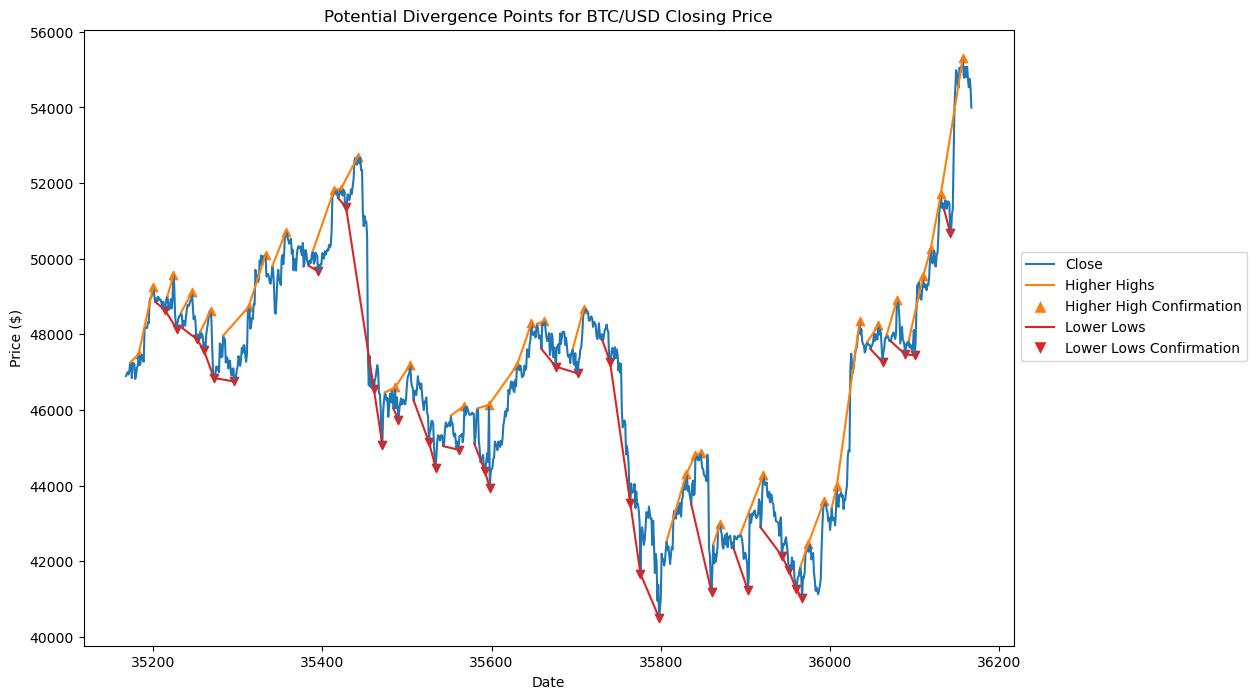

In [139]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.figure(figsize=(12, 8))
plt.plot(tdf['close'])
plt.scatter(dates[hh_idx], price[hh_idx], marker='^', c=colors[1])
plt.scatter(dates[ll_idx], price[ll_idx], marker='v', c=colors[3])
_ = [plt.plot(dates[i], price[i], c=colors[1]) for i in hh]
_ = [plt.plot(dates[i], price[i], c=colors[3]) for i in ll]
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.title('Potential Divergence Points for BTC/USD Closing Price')
legend_elements = [
  Line2D([0], [0], color=colors[0], label='Close'),
  Line2D([0], [0], color=colors[1], label='Higher Highs'),
  Line2D([0], [0], color='w',  marker='^',
         markersize=10,
         markerfacecolor=colors[1],
label='Higher High Confirmation'),
Line2D([0], [0], color=colors[3], label='Lower Lows'),
  Line2D([0], [0], color='w',  marker='v',
         markersize=10,
         markerfacecolor=colors[3],
         label='Lower Lows Confirmation')
]
plt.legend(handles=legend_elements, bbox_to_anchor=(1, 0.65))
plt.show()

In [87]:
ttdf = df.tail(1000)
ttdf.columns = [col.lower() for col in ttdf.columns]
the_rsi = ta.RSI(ttdf, timeperiod= 14)

In [90]:
type(the_rsi)

pandas.core.series.Series

In [93]:
# insert hh idx into the df
tdf['rsi'] = the_rsi
tdf.columns = [ col.lower() for col in tdf.columns]
tdf

,date,close,rsi
35168,2021-08-26 16:00:00,46897.72,NaN
35169,2021-08-26 17:00:00,46950.26,NaN
35170,2021-08-26 18:00:00,47001.46,NaN
35171,2021-08-26 19:00:00,46939.75,NaN
35172,2021-08-26 20:00:00,47017.57,NaN
...,...,...,...
36163,2021-10-07 05:00:00,54735.76,62.838693
36164,2021-10-07 06:00:00,54534.16,59.678968
36165,2021-10-07 07:00:00,54755.92,61.945715
36166,2021-10-07 08:00:00,54538.30,58.471808


In [140]:
rsi_hh = getHigherHighs(tdf['rsi'].values)
rsi_ll = getLowerLows(tdf['rsi'].values)

In [141]:
adeque

deque([24, 42])

In [142]:
adeque[-1]

42

In [145]:
anarr = np.array([1,2,3,4,5,6,7,8,9,10])
anarr_greater7 = np.where(anarr> 7)
anarr_greater7

(array([7, 8, 9], dtype=int64),)

In [156]:
def getHHIndex(arr: np.array, width=5, k=2):
  extrema = getHigherHighs(arr, width, k) # [deque([idx1, idx2])]
  # idx = np.array([i[-1] + width for i in extrema])
  idx = np.array([i[-1] for i in extrema])
  return idx

def getLLIndex(arr:np.array, width=5, k=2):
  extrema = getLowerLows(arr, width, k)
  idx = np.array([i[-1] for i in extrema])
  return idx

In [159]:
rsi_hh_idx = getHHIndex(tdf['rsi'].values)
rsi_ll_idx = getLLIndex(tdf['rsi'].values)

In [161]:
price = tdf['close'].values
rsi = tdf['rsi'].values

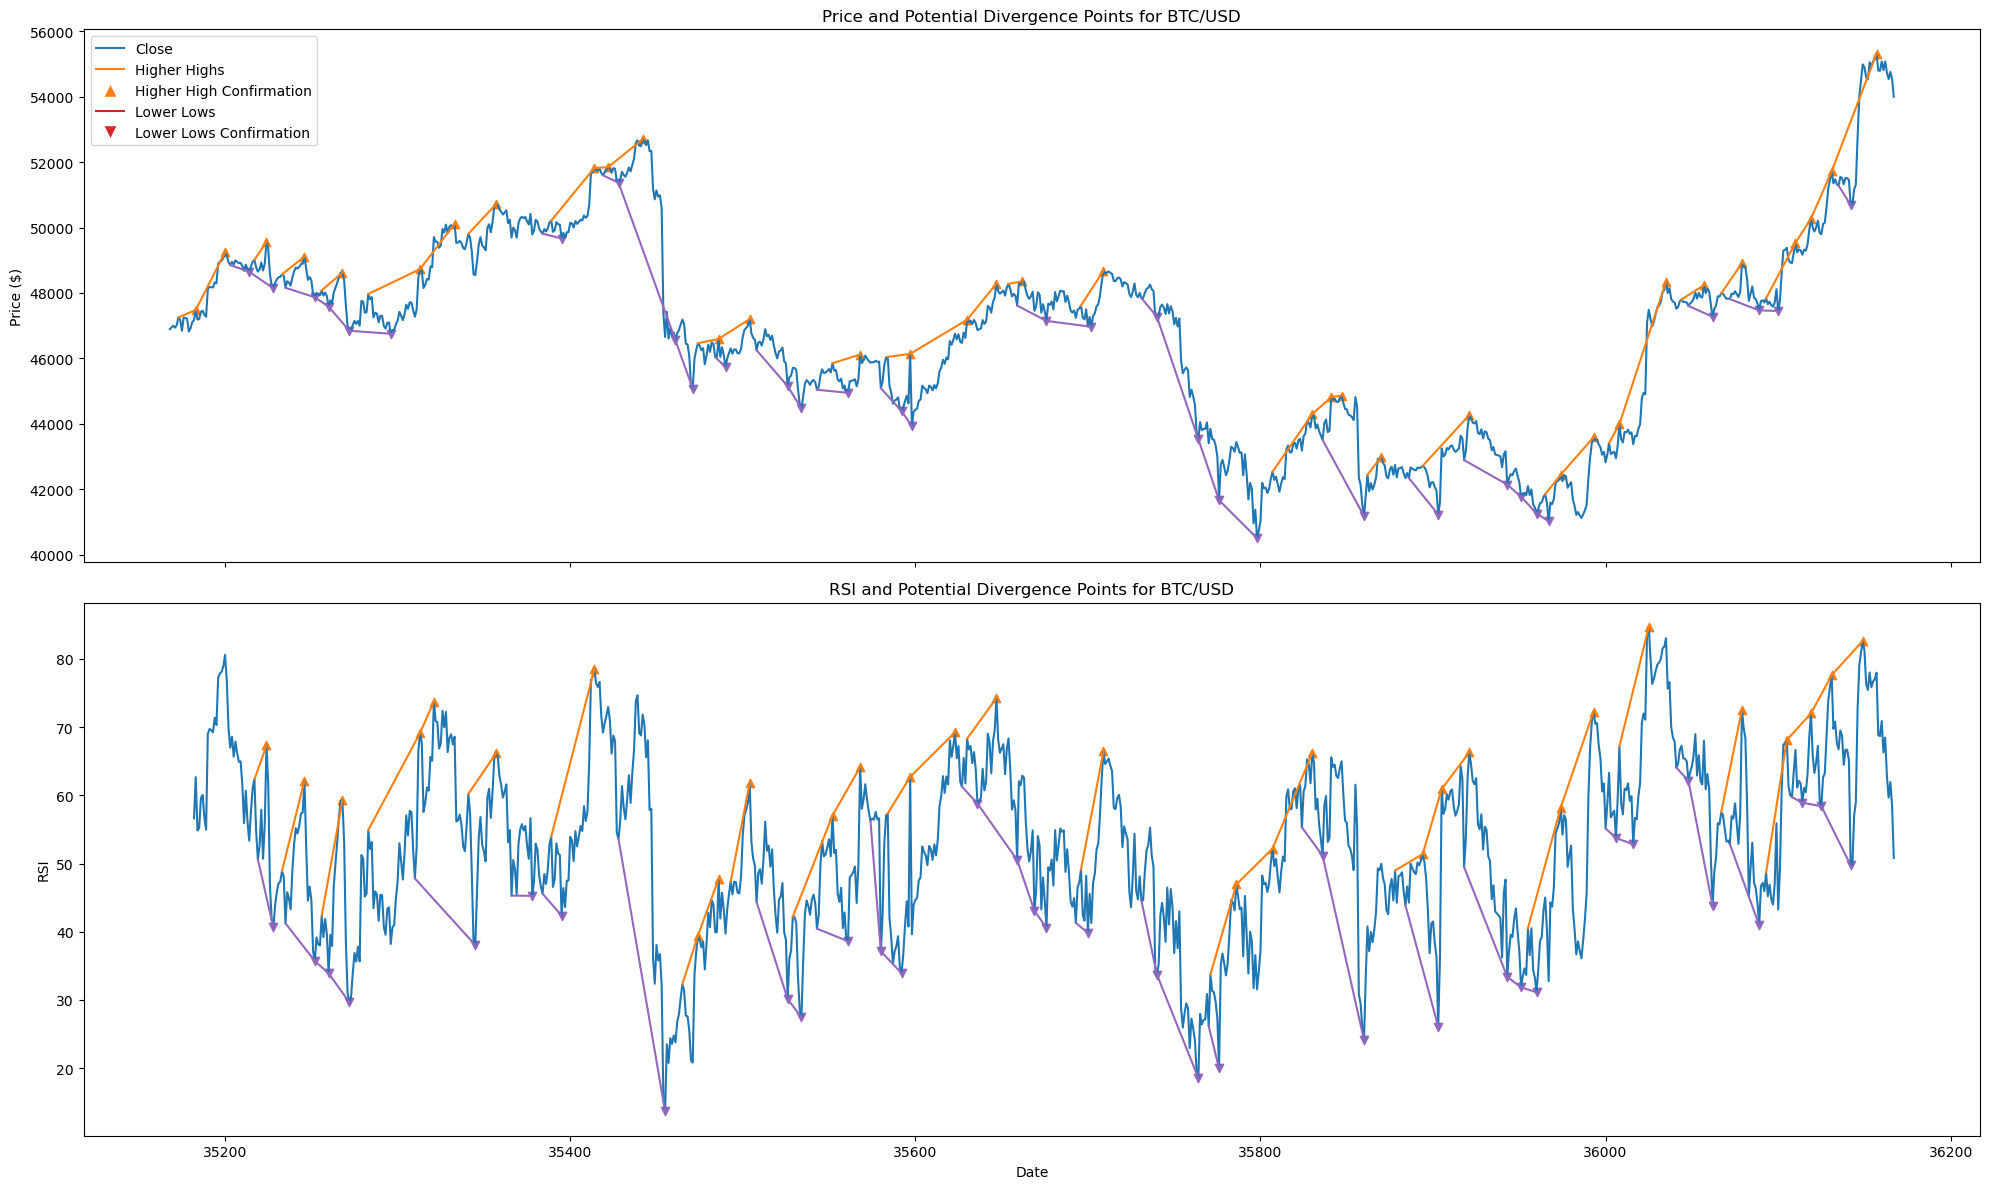

In [162]:
fig, ax = plt.subplots(2, figsize=(20, 12), sharex=True)
ax[0].plot(tdf['close'])
ax[0].scatter(dates[hh_idx], price[hh_idx], 
              marker='^', c=colors[1])
ax[0].scatter(dates[ll_idx], price[ll_idx],
              marker='v', c=colors[4])
_ = [ax[0].plot(dates[i], price[i], c=colors[1]) for i in hh]
_ = [ax[0].plot(dates[i], price[i], c=colors[4]) for i in ll]
ax[0].set_ylabel('Price ($)')
ax[0].set_title('Price and Potential Divergence Points for BTC/USD')
ax[0].legend(handles=legend_elements)
ax[1].plot(tdf['rsi'])
ax[1].scatter(dates[rsi_hh_idx], rsi[rsi_hh_idx], 
              marker='^', c=colors[1])
ax[1].scatter(dates[rsi_ll_idx], rsi[rsi_ll_idx],
              marker='v', c=colors[4])
_ = [ax[1].plot(dates[i], rsi[i], c=colors[1]) for i in rsi_hh]
_ = [ax[1].plot(dates[i], rsi[i], c=colors[4]) for i in rsi_ll]
ax[1].set_ylabel('RSI')
ax[1].set_title('RSI and Potential Divergence Points for BTC/USD')
ax[1].set_xlabel('Date')
plt.tight_layout()
plt.show()

In [163]:
tdf

,date,close,rsi
35168,2021-08-26 16:00:00,46897.72,NaN
35169,2021-08-26 17:00:00,46950.26,NaN
35170,2021-08-26 18:00:00,47001.46,NaN
35171,2021-08-26 19:00:00,46939.75,NaN
35172,2021-08-26 20:00:00,47017.57,NaN
...,...,...,...
36163,2021-10-07 05:00:00,54735.76,62.838693
36164,2021-10-07 06:00:00,54534.16,59.678968
36165,2021-10-07 07:00:00,54755.92,61.945715
36166,2021-10-07 08:00:00,54538.30,58.471808


In [164]:
df

,Date,Open,High,Low,Close,Volume,divergence
0,2017-08-17 04:00:00.000,4261.48,4313.62,4261.32,4308.83,47.181009,NaN
1,2017-08-17 05:00:00.000,4308.83,4328.69,4291.37,4315.32,23.234916,NaN
2,2017-08-17 06:00:00.000,4330.29,4345.45,4309.37,4324.35,7.229691,NaN
3,2017-08-17 07:00:00.000,4316.62,4349.99,4287.41,4349.99,4.443249,NaN
4,2017-08-17 08:00:00.000,4333.32,4377.85,4333.32,4360.69,0.972807,NaN
...,...,...,...,...,...,...,...
36163,2021-10-07 05:00:00,55073.20,55073.21,54545.07,54735.76,2251.122020,NaN
36164,2021-10-07 06:00:00,54735.77,54968.06,54375.83,54534.16,1783.004260,NaN
36165,2021-10-07 07:00:00,54534.16,54793.26,54235.33,54755.92,4163.431360,NaN
36166,2021-10-07 08:00:00,54755.91,54778.91,54400.00,54538.30,2049.382180,NaN


In [165]:
df1 = df.tail(2000)

### Divergence detection

In [ ]:
def divergence(df: pd.Dataframe, width = 5):
    # get pivots 
    hh = getHigherHighs(price,width) # List[deque([h1_idx, h2_idx])]
    ll = getLowerLows(price, width)
    rsi_hh = getHigherHighs(rsi, width)
    rsi_ll = getLowerLows(rsi, width)

    #get confirmation indices
    hh_idx = np.array([i[-1] for i in hh]) # i is deque([h1_idx, h2_idx]) => h2_idx
    ll_idx = np.array([i[-1] for i in ll]) # l2_idx

    # divergence detection
    # bull_divergence
    # get idx of low2_idx

    # calculating slope for price and rsi for each  hh and ll
    

    # insert slope values into df by np.where

    # get slope@df.iloc[(low2_idx-width)]['rsi_slope']

    # bull_divergence = (slope<0 and rsi_slope)>0? True: False
    